# **ML Model:**  eXtreme Gradinet Boosting

## **Notes:**

**XGBoost** (eXtreme Gradient Boosting) is the second advanced model compared against the baselines.

Unlike Random Forest (bagging — parallel trees), XGBoost uses **boosting**: each tree learns from the mistakes of the previous one, iteratively reducing errors.

Key advantages over Random Forest:
- Learns sequentially → better on hard-to-classify samples
- Built-in regularization (L1/L2) → less overfitting
- `scale_pos_weight` handles class imbalance more precisely than balanced weighting
- Generally stronger on tabular data

Hyperparameter tuning is done via **RandomizedSearchCV** with cross-validation.

## **Implementation:**

#### Librabry imports

In [31]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from xgboost import XGBClassifier

In [32]:
sys.path.append(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'scripts'))

In [33]:
from utils import eval_model, print_report, save_results, load_results, load_info, split_info  # type: ignore

### **Load data**

In [34]:
data = pd.read_excel('../data/processed/accident_processed_srb.xlsx')

In [35]:
load_info(df=data)

Shape: (205352, 16)
Columns: ['municipality', 'longitude', 'latitude', 'accident_type', 'month', 'day_of_week', 'hour', 'day_type', 'is_rush', 'is_night', 'season', 'acc_parked_vehicles', 'acc_pedestrians', 'acc_single_vehicle', 'acc_two_vehicles_no_turn', 'acc_two_vehicles_turn_or_cross']
Number of coumnts: 16
Target distribution: accident_type
0    0.597
1    0.403
Name: proportion, dtype: float64


In [36]:
y = data['accident_type']
X = data.drop(columns=['accident_type'])

### **Split data**

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
split_info(X_train, X_test, y_train, y_test)

Rows number (Train): 164281
Rows number (Test): 41071
Target distribution (Train): {0: 0.597, 1: 0.403}
Target distribution (Test): {0: 0.597, 1: 0.403}


Target encoding for municipality — consistent with previous models.

In [39]:
mun_encoder = ce.TargetEncoder(cols=['municipality'])

In [40]:
X_train['municipality'] = mun_encoder.fit_transform(X_train['municipality'], y_train)
X_test['municipality']  = mun_encoder.transform(X_test['municipality'])

XGBoost uses `scale_pos_weight` instead of `class_weight='balanced'`.

Formula: number of negative samples / number of positive samples.

In [41]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative (Material):     {neg}")
print(f"Positive (Injured/Dead): {pos}")
print(f"scale_pos_weight:        {scale_pos_weight:.4f}")

Negative (Material):     98036
Positive (Injured/Dead): 66245
scale_pos_weight:        1.4799


### **Training**

In [42]:
xgb_model = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    n_jobs=-1
)

In [43]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### **Evaluation**

In [44]:
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]


In [45]:
results = eval_model(
    model_name = 'XGBoost (Baseline)',
    y_test = y_test,
    y_pred = y_pred,
    y_pred_prob = y_pred_prob,
    target_names = ['Material', 'Injured/Dead']
)

In [46]:
print_report(
    y_test = y_test,
    y_pred = y_pred,
    results = results,
    target_names = ['Material', 'Injured/Dead']
)

XGBoost (Baseline)
              precision    recall  f1-score   support

    Material       0.79      0.74      0.76     24509
Injured/Dead       0.64      0.71      0.67     16562

    accuracy                           0.72     41071
   macro avg       0.72      0.72      0.72     41071
weighted avg       0.73      0.72      0.73     41071

ROC-AUC value: 0.8025


### **Additional**

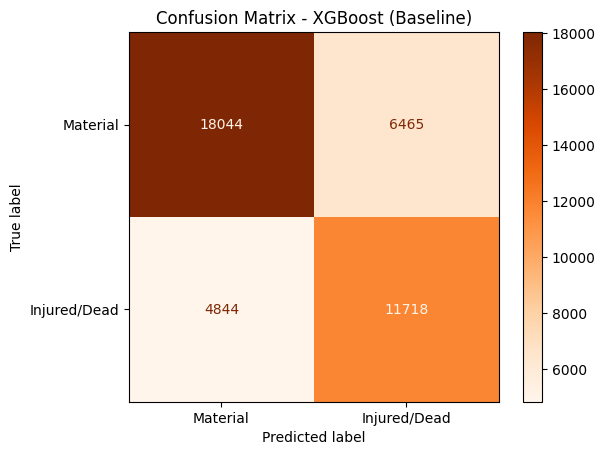

In [47]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Material', 'Injured/Dead'],
    cmap='Oranges'
)
plt.title("Confusion Matrix - XGBoost (Baseline)")
plt.show()

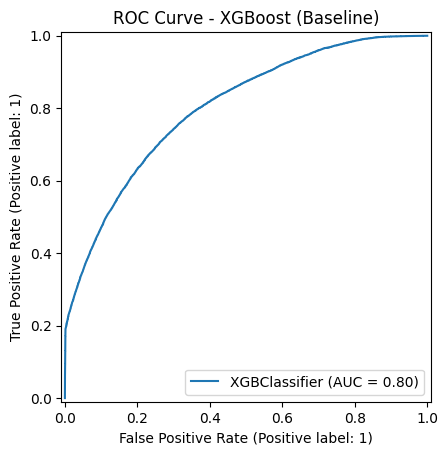

In [48]:
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("ROC Curve - XGBoost (Baseline)")
plt.show()

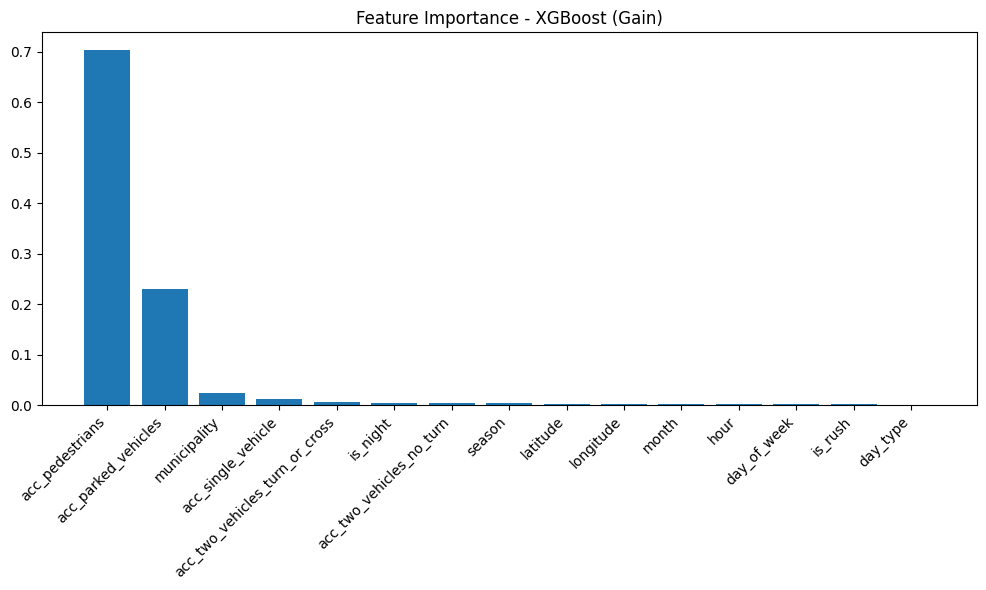

acc_pedestrians                     0.7029
acc_parked_vehicles                 0.2291
municipality                        0.0245
acc_single_vehicle                  0.0125
acc_two_vehicles_turn_or_cross      0.0053
is_night                            0.0051
acc_two_vehicles_no_turn            0.0044
season                              0.0036
latitude                            0.0025
longitude                           0.0024
month                               0.0023
hour                                0.0022
day_of_week                         0.0017
is_rush                             0.0017
day_type                            0.0000


In [ ]:
feature_names = X_train.columns
importances = xgb_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sorted_idx])
plt.xticks(range(len(importances)), feature_names[sorted_idx], rotation=45, ha='right')
plt.title("Feature Importance - XGBoost (Gain)")
plt.tight_layout()
plt.show()

for i in sorted_idx:
    print(f"{feature_names[i]:<35} {importances[i]:.4f}")

In [50]:
save_results(results)

In [51]:
joblib.dump(xgb_model,   '../models/xgboost_baseline.pkl')
joblib.dump(mun_encoder, '../models/encoders/xgb_mun_target_encoder.pkl')

['../models/encoders/xgb_mun_target_encoder.pkl']

### **Tuning**

In [52]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2],
}

In [55]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    estimator = XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        n_jobs=-1
    ),
    param_distributions = param_dist,
    n_iter = 40,
    scoring = 'roc_auc',
    cv = cv,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

In [56]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [200, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

In [57]:
print("Best parameters:")
print(xgb_search.best_params_)
print(f"\nBest CV AUC: {xgb_search.best_score_:.4f}")

Best parameters:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best CV AUC: 0.8023


In [58]:
xgb_model_tuned = xgb_search.best_estimator_

In [59]:
y_pred = xgb_model_tuned.predict(X_test)
y_pred_prob = xgb_model_tuned.predict_proba(X_test)[:, 1]


In [60]:
results = eval_model(
    model_name  = 'XGBoost (Tuned)',
    y_test = y_test,
    y_pred = y_pred,
    y_pred_prob = y_pred_prob,
    target_names = ['Material', 'Injured/Dead']
)

In [61]:
print_report(
    y_test = y_test,
    y_pred = y_pred,
    results = results,
    target_names = ['Material', 'Injured/Dead']
)

XGBoost (Tuned)
              precision    recall  f1-score   support

    Material       0.79      0.73      0.76     24509
Injured/Dead       0.64      0.71      0.68     16562

    accuracy                           0.72     41071
   macro avg       0.72      0.72      0.72     41071
weighted avg       0.73      0.72      0.73     41071

ROC-AUC value: 0.8031


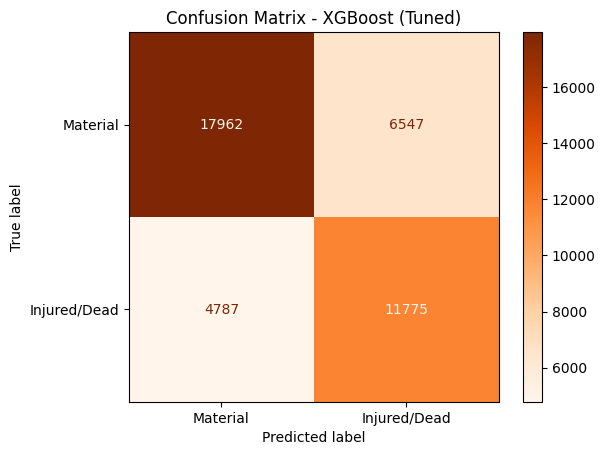

In [62]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Material', 'Injured/Dead'],
    cmap='Oranges'
)
plt.title("Confusion Matrix - XGBoost (Tuned)")
plt.show()

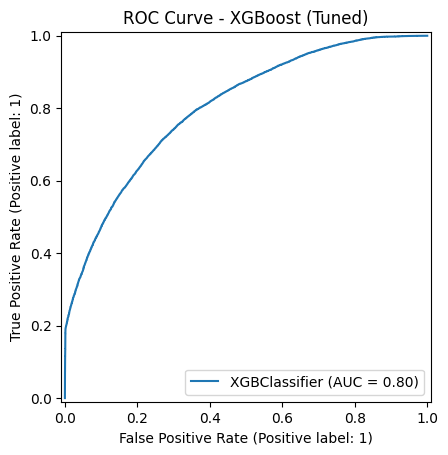

In [63]:
RocCurveDisplay.from_estimator(xgb_model_tuned, X_test, y_test)
plt.title("ROC Curve - XGBoost (Tuned)")
plt.show()

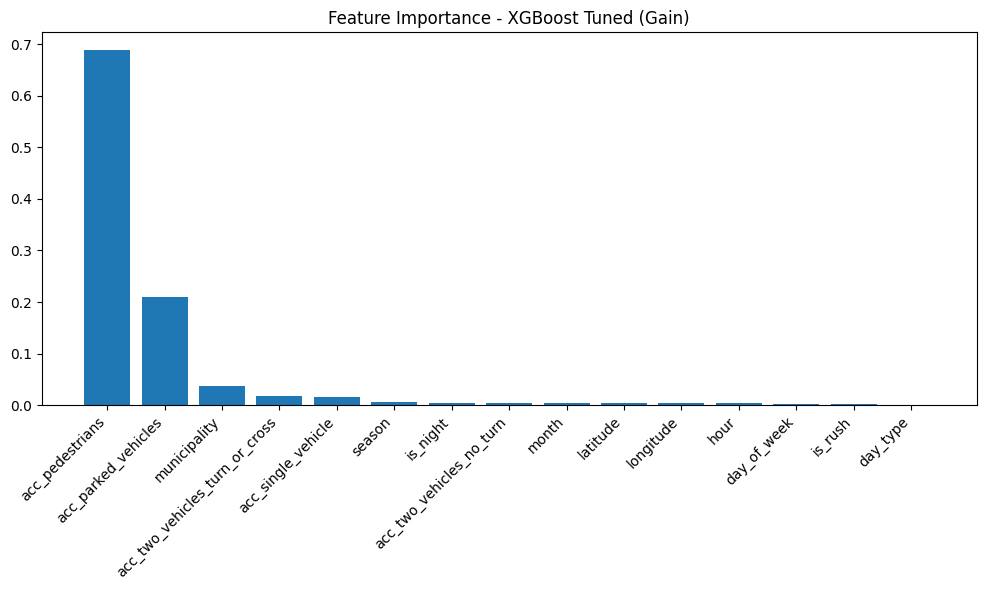

acc_pedestrians                     0.6886
acc_parked_vehicles                 0.2088
municipality                        0.0362
acc_two_vehicles_turn_or_cross      0.0176
acc_single_vehicle                  0.0152
season                              0.0058
is_night                            0.0046
acc_two_vehicles_no_turn            0.0039
month                               0.0037
latitude                            0.0035
longitude                           0.0035
hour                                0.0035
day_of_week                         0.0026
is_rush                             0.0025
day_type                            0.0000


In [64]:
feature_names = X_train.columns
importances = xgb_model_tuned.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sorted_idx])
plt.xticks(range(len(importances)), feature_names[sorted_idx], rotation=45, ha='right')
plt.title("Feature Importance - XGBoost Tuned (Gain)")
plt.tight_layout()
plt.show()

for i in sorted_idx:
    print(f"{feature_names[i]:<35} {importances[i]:.4f}")

In [65]:
save_results(results)

In [66]:
joblib.dump(xgb_model_tuned, '../models/xgboost_tuned.pkl')

['../models/xgboost_tuned.pkl']